In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/raw/housing_sp_city.csv', encoding='latin1')

## 1. Panorama Inicial do Dataset (Volume de Vendas vs. Locação)

Antes de restringir o escopo do projeto para o modelo preditivo de vendas, realizo uma contagem volumétrica para entender a distribuição dos tipos de anúncios presentes na base de dados bruta de São Paulo.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 133964 entries, 0 to 133963
Data columns (total 18 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   logradouro       126962 non-null  str    
 1   numero           89823 non-null   str    
 2   bairro           133943 non-null  str    
 3   cep              128056 non-null  float64
 4   cidade           133964 non-null  str    
 5   tipo_imovel      133964 non-null  str    
 6   area_util        130868 non-null  float64
 7   banheiros        133051 non-null  float64
 8   suites           120347 non-null  float64
 9   quartos          130945 non-null  float64
 10  vagas_garagem    129539 non-null  float64
 11  anuncio_criado   133964 non-null  str    
 12  tipo_anuncio     133964 non-null  str    
 13  preco_venda      133964 non-null  int64  
 14  taxa_condominio  117127 non-null  float64
 15  periodicidade    29051 non-null   str    
 16  preco_aluguel    28714 non-null   float64
 17  ip

In [4]:
df.head()

,logradouro,numero,bairro,cep,cidade,tipo_imovel,area_util,banheiros,suites,quartos,vagas_garagem,anuncio_criado,tipo_anuncio,preco_venda,taxa_condominio,periodicidade,preco_aluguel,iptu_ano
0,Rua Juvenal Galeno,53,Jardim da SaÃºde,4290030.0,SÃ£o Paulo,Casa de dois andares,388.0,3.0,1.0,4.0,6.0,2017-02-07,Venda,700000,NaN,NaN,NaN,NaN
1,Rua Juruaba,16,Vila Santa Teresa (Zona Sul),4187320.0,SÃ£o Paulo,Casa,129.0,2.0,1.0,3.0,2.0,2016-03-21,Venda,336000,NaN,NaN,NaN,NaN
2,Avenida Paulista,402,Bela Vista,1311000.0,SÃ£o Paulo,Comercial,396.0,4.0,0.0,0.0,5.0,2018-12-18,LocaÃ§Ã£o,24929,4900.0,MONTHLY,29829.0,4040.0
3,Rua Alvorada,1190,Vila OlÃ­mpia,4550004.0,SÃ£o Paulo,Apartamento,80.0,2.0,1.0,3.0,2.0,2018-10-26,Venda,739643,686.0,NaN,NaN,1610.0
4,Rua Curitiba,380,ParaÃ­so,4005030.0,SÃ£o Paulo,Apartamento,3322.0,5.0,4.0,4.0,5.0,2018-12-14,Venda,7520099,6230.0,NaN,NaN,18900.0


In [5]:
# Contabilizo a quantidade absoluta e a proporção percentual de cada tipo de anúncio na base bruta
total_por_tipo = df['tipo_anuncio'].value_counts()
porcentagem_por_tipo = df['tipo_anuncio'].value_counts(normalize=True) * 100

In [6]:
# Exibo os resultados consolidados
for tipo, qtd in total_por_tipo.items():
    pct = porcentagem_por_tipo[tipo]
    print(f"Tipo de Anúncio: {tipo} | Quantidade: {qtd:,} Imóveis | Proporção: {pct:.2f}%")

Tipo de Anúncio: Venda | Quantidade: 105,332 Imóveis | Proporção: 78.63%
Tipo de Anúncio: LocaÃ§Ã£o | Quantidade: 28,632 Imóveis | Proporção: 21.37%


## 2. Filtragem do Escopo e Tratamento de Nulos ($NaN$)

Para garantir que o modelo aprenda a dinâmica correta de precificação de compra e venda, preciso isolar os dados de locação. Durante a análise sensorial dos dados, identifiquei que as colunas `preco_aluguel` e `periodicidade` pertencem ao ecossistema de locação, enquanto as taxas de condomínio nulas refletem imóveis isentos (como casas de rua).

In [7]:
# 1. Filtrando apenas os imovéis a venda
# Como a palavra "locação" está quebrada, vamos uysar a estratégia inversa:
# Mantes apenas onde o tipo_anuncio for exatamente "venda"
df_venda = df[df['tipo_anuncio'] == 'Venda'].copy()

In [8]:
# 2. tratando os NaN do condomínio
df_venda['taxa_condominio'] = df_venda['taxa_condominio'].fillna(0)

In [9]:
total_bairros = df_venda['bairro'].nunique()
print(f'Total de imóveis após filtrar por venda: {df_venda.shape[0]}')
print(f'Quantidade de bairros únicos na cidade de SP: {total_bairros}')

Total de imóveis após filtrar por venda: 105332
Quantidade de bairros únicos na cidade de SP: 1687


In [10]:
df['tipo_anuncio'].unique()

<StringArray>
['Venda', 'LocaÃ§Ã£o']
Length: 2, dtype: str

## 3. Inspeção de Estatísticas Descritivas e Outliers

Com a base de vendas consolidada, analiso as métricas estatísticas das variáveis de preço e área para identificar anomalias nos valores mínimos e máximos antes de iniciar as plotagens gráficas.

In [11]:
# Analiso as estatísticas descritivas das variáveis críticas do modelo
df_venda[['preco_venda', 'area_util']].describe()

,preco_venda,area_util
count,1.053320e+05,1.027630e+05
mean,8.415624e+05,1.972619e+02
std,1.434909e+06,6.477093e+03
min,7.000000e+03,1.000000e+00
25%,2.968000e+05,6.400000e+01
50%,4.822990e+05,1.050000e+02
75%,8.869000e+05,1.820000e+02
max,8.400000e+07,2.025000e+06


## 4. Identificação de Anomalias e Outliers

Ao analisar os extremos dos dados, identifiquei inconsistências severas de cadastro: imóveis com área útil de 1m² ou superiores a 2 milhões de m², além de preços de venda irreais de R$ 7.000. Para facilitar a leitura e o planejamento do corte desses *outliers*, configuro o Pandas para exibir os dados em formato decimal.

In [12]:
# Mudo a configuração do Pandas para exibir floats com duas casas decimais, 
# eleminando a notação cientifica que dificulta a interpretação de valores financeiros
def formatar_metricas(valor):
    return f"{valor:,.2f}"

In [13]:
# Reapresento a descrição estatística para validar a leitura dos extremos
df_venda[['preco_venda', 'area_util']].describe().style.format(formatar_metricas)

,preco_venda,area_util
count,"105,332.00","102,763.00"
mean,"841,562.35",197.26
std,"1,434,908.50","6,477.09"
min,"7,000.00",1.00
25%,"296,800.00",64.00
50%,"482,299.00",105.00
75%,"886,900.00",182.00
max,"84,000,000.00","2,025,000.00"


## 4. Filtragem de Sanidade Baseada em Regras de Negócio

Para eliminar os erros grosseiros de cadastro (como imóveis de 1m² ou valores equivalentes a aluguéis), estabeleço limites mínimos e máximos realistas para o mercado de São Paulo. Defino como corte: área útil entre 15m² e 5.000m², e preço de venda a partir de R$ 80.000, isolando anomalias que prejudicariam o aprendizado dos modelos de regressão.

In [14]:
# Aplicando os limites de corte baseado na análise econômica de mercado
df_limpo = df_venda[
    (df_venda['area_util'] >= 15) &
    (df_venda['area_util'] <= 5000) &
    (df_venda['preco_venda'] >=8000)
].copy()

In [15]:
print(f'Total de imóveis após a limpeza {df_limpo.shape[0]}')

Total de imóveis após a limpeza 102515


## 5. Engenharia de Recursos: Cálculo do Preço por Metro Quadrado ($\text{R\$}/m^2$)

Crio a variável `preco_m2` dividindo o valor total de venda pela área útil. Essa métrica é fundamental para a análise imobiliária, pois normaliza os valores, permitindo identificar distorções remanescentes e servindo como base para avaliar o comportamento econômico dos bairros de alta cardinalidade.

In [16]:
# Criando a nova feature calculando a razão entre o preço e o tamanho do imovel
df_limpo['preco_m2'] = df_limpo['preco_venda'] / df_limpo['area_util']

In [17]:
df_limpo['preco_m2'].describe().to_frame().style.format(formatar_metricas)

,preco_m2
count,"102,515.00"
mean,"5,424.30"
std,"5,398.01"
min,31.16
25%,"3,499.99"
50%,"4,783.33"
75%,"6,695.65"
max,"1,215,789.47"


## 6. Refinamento de Outliers pelo Preço do Metro Quadrado

A criação da métrica `preco_m2` revelou distorções extremas que passaram pelos filtros anteriores, apresentando valores impraticáveis no mercado real (mínimo de R$ 31,16/m² e máximo de R$ 1.215.789,47/m²). Para sanar isso, aplico um novo corte mantendo apenas imóveis cujo valor por metro quadrado esteja entre R$ 2.000 e R$ 50.000, faixas que compreendem desde habitações populares até o altíssimo padrão paulistano.

In [18]:
# Aplico o filtro definitivo baseado no valor do metro quadrado real de SP
df_final = df_limpo[
    (df_limpo['preco_m2'] >= 2000) &
    (df_limpo['preco_m2'] <= 50000)
].copy()


In [19]:
print(f'Total de imóveis após o refino do preço/m²: {df_final.shape[0]}')

Total de imóveis após o refino do preço/m²: 98357


In [20]:
df_final['bairro'].nunique()

1561

## 7. Fase 2 - Tratamento de Alta Cardinalidade e Padronização de Categóricos

Identifiquei que, mesmo após a limpeza de outliers, a base mantém 1.561 bairros únicos, um volume muito superior aos bairros oficiais de São Paulo. Isso evidencia problemas de padronização textual. Nesta etapa, inicio a normalização aplicando transformações para remover espaços em branco e padronizar a caixa do texto, mitigando duplicidades básicas de cadastro.

In [21]:
# Removendo espaços em branco extras no início e no fim das strings
df_final['bairro'] = df_final['bairro'].str.strip()

In [22]:
# Padronizando todas as strings do campo bairro para letras maiúscuas,
# eliminando a difrença entre 'Vila Mariana', 'vila mariana' e 'VILA MARIANA'
df_final['bairro'] = df_final['bairro'].str.upper()

In [23]:
# Verifico quantos bairros únicos restaram após essa primeira padronização simples
bairros_apos_limpeza = df_final['bairro'].nunique()
print(f'Quantidade de bairros únicos após padronização de texto: {bairros_apos_limpeza}')

Quantidade de bairros únicos após padronização de texto: 1553


## 8. Inspeção Visual da Alta Cardinalidade

Para não realizar tratamentos às cegas, analiso os extremos da coluna `bairro`. Verifico os bairros com menor volume de anúncios para identificar inconsistências de digitação, abreviações incorretas e registros que não correspondem a bairros reais de São Paulo.

In [25]:
# Agrupo por bairro para contar quantos imóveis existem em cada um e ordeno do menor para o maior para expor os erros!
contagem_bairros = df_final['bairro'].value_counts()

In [26]:
print('--- Os 30 bairro com menos imóveis no dataset ---')
print(contagem_bairros.tail(30))

--- Os 30 bairro com menos imóveis no dataset ---
bairro
JARDIM MONTE ALEGRE (ZONA NORTE)    1
JARDIM SANTA LUCRECIA               1
JARDIM SANTA CRUZ (ZONA NORTE)      1
JARDIM MARIA EUGÃªNIA               1
JARDIM SANTO ALBERTO                1
VILA FIDALGO                        1
CHÃ¡CARA FIGUEIRA GRANDE            1
RUA FRANCISCA JÃºLIA                1
RUA MOTAN                           1
VILA GENIOLI                        1
CHÃ¡CARA MARIA TRINDADE             1
VILA JOÃ£O BATISTA                  1
CONJUNTO CITY JARAGUÃ¡              1
RUA ANDRÃ© CHENIER                  1
CORONEL SEZEFREDO FAGUNDES          1
JARDIM SÃ£O LUÃ­S (ZONA NORTE)      1
JARDIM BRASILIA (ZONA NORTE)        1
JARDIM ITÃ¡LIA                      1
SANO PAULO                          1
CHÃ¡DOUTOR CÃ¢NDIDO                 1
JARDIM AURORA                       1
JARDIM LAGEADO                      1
GUAIAUNA                            1
JARDIM COIMBRA                      1
LAGEADO                        

In [27]:
print('\n--- Amostra Aleatória de bairros para inspecionar grafia ---')
print(contagem_bairros.sample(30, random_state=42))


--- Amostra Aleatória de bairros para inspecionar grafia ---
bairro
JARDIM SAO JOSE (ZONA NORTE)       1
JAÃ§ANÃ£                          61
ERMELINO MATARAZZO                37
JARDIM SARAH                      36
VILA SAO FRANCISCO                 2
JARDIM SÃ£O PAULO(ZONA NORTE)     73
PARQUE SAO DOMINGOS               37
JARDIM PICOLO                      5
VILA BEATRIZ                      25
JARDIM LEONIDAS MOREIRA            1
COHAB TAIPAS                       2
SÃ£O DOMINGOS                     37
VILA PIRITUBA                    340
VILA DA PAZ                        1
VILA FORMOSA                     805
VILA CURUÃ§Ã¡                      1
VILA HOMERO                        5
VILA CAIÃºBA                       1
JARDIM DA SAÃºDE                 112
VILA AMÃ¡LIA (ZONA NORTE)        115
VILA SAO LUIS                      3
VILA ANTONIO                       3
FAZENDA ARICANDUVA                16
SÃ­TIO DO PIQUERI                  2
JARDIM INDEPENDENCIA              16
CIDADE

## 8. Filtro de Frequência para Redução de Alta Cardinalidade

Ao inspecionar a amostra de bairros, constatei que a base sofre com problemas severos de caracteres corrompidos (`JAÃ§ANÃ£`, `SÃ£O DOMINGOS`) e uma longa cauda de bairros com apenas 1 ou 2 imóveis cadastrados. Para garantir consistência estatística e permitir que o modelo aprenda padrões reais de preços, estabeleço um ponto de corte: mantenho na base apenas os bairros que possuem no mínimo 30 anúncios cadastrados.

In [28]:
# Conto a frequência de cada bairro novamente
frequencia_bairros = df_final['bairro'].value_counts()

In [30]:
# Identifico quais bairros possuem 30 ou mais imóveis cadastrado
bairros_com_volume_minimo = frequencia_bairros[frequencia_bairros >= 30].index

In [31]:
# filtro o dataframe mantendo apenas os registros desses bairros selecionados
df_final = df_final[df_final['bairro'].isin(bairros_com_volume_minimo)].copy()

In [32]:
# Verificando a nova quantidade de bairros únicos e o volume total de imóveis restante
bairros_restantes = df_final['bairro'].nunique()
imoveis_restantes = df_final.shape[0]

In [33]:
print(f'Quantidade de bairros únicos após o filtro de frequência: {bairros_restantes}')
print(f'total de imóveis restantes na base: {imoveis_restantes}')

Quantidade de bairros únicos após o filtro de frequência: 395
total de imóveis restantes na base: 91242


## 9. Salvamento da Base de Dados Tratada

Com as etapas de saneamento de outliers e redução de alta cardinalidade concluídas com sucesso, exporto o DataFrame resultante para a pasta de dados processados. Esse arquivo servirá como a base limpa e oficial para as próximas etapas de análise exploratória visual e modelagem preditiva.

In [35]:
df_final.to_csv('../data/processed/vendas_sp_limpo.csv', index=False)
print('Bases de dados limpa exportada com sucesso')

Bases de dados limpa exportada com sucesso


## 10. Fase 3 - Análise Exploratória de Dados Visual (EDAV)

Com a base devidamente saneada e consolidada, inicio a análise exploratória visual. O objetivo nesta etapa é mapear a distribuição de frequência das variáveis contínuas (`preco_venda` e `area_util`) através de histogramas e curvas de densidade, avaliando o comportamento real do mercado imobiliário paulistano após a remoção dos ruídos.

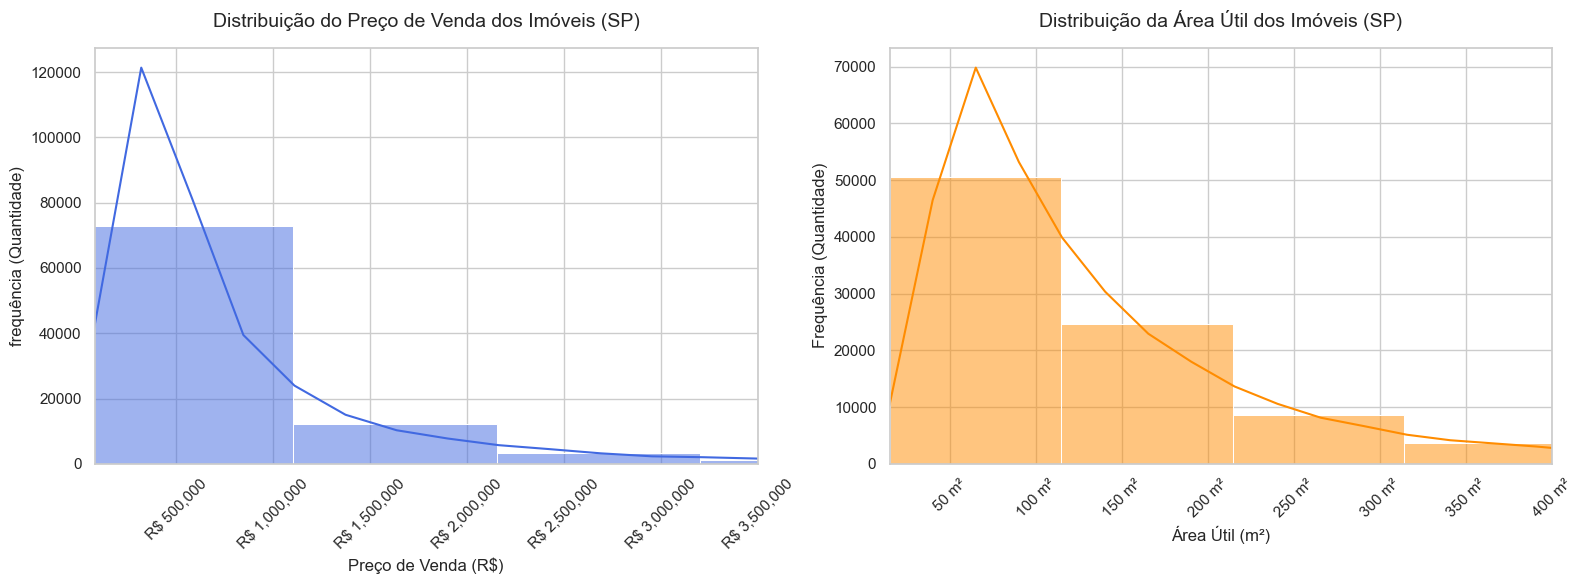

In [43]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(16,6))

# --- Grafico 1: Distribuição dos Preços de venda ---
plt.subplot(1, 2, 1)
sns.histplot(data=df_final, x='preco_venda', bins=50, kde=True, color='royalblue')
plt.title('Distribuição do Preço de Venda dos Imóveis (SP)', fontsize=14, pad=15)
plt.xlabel('Preço de Venda (R$)', fontsize=12)
plt.ylabel('frequência (Quantidade)', fontsize=12)

# Aplicamos o zoom limitando o eixo X de R$ 80 mil até R$ 3.5 Milhões
plt.xlim(80000, 3500000)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"R$ {x:,.0f}"))
plt.xticks(rotation=45)

# --- GRÁFICO 2: Distribuição da Área Útil ---
plt.subplot(1, 2, 2)
sns.histplot(data=df_final, x='area_util', bins=50, kde=True, color='darkorange')
plt.title('Distribuição da Área Útil dos Imóveis (SP)', fontsize=14, pad=15)
plt.xlabel('Área Útil (m²)', fontsize=12)
plt.ylabel('Frequência (Quantidade)', fontsize=12)

# Aplicamos o zoom limitando o eixo X de 15m² até 400m²
plt.xlim(15, 400)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f} m²"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 11. Análise de Correlação Linear (Preço vs. Área Útil)

Com o comportamento isolado das variáveis compreendido, cruzo as dimensões de `area_util` e `preco_venda` em um gráfico de dispersão. Utilizo opacidade reduzida nos pontos para identificar visualmente as zonas de maior densidade de mercado e avaliar a força da relação linear que guiará nossos modelos de regressão.

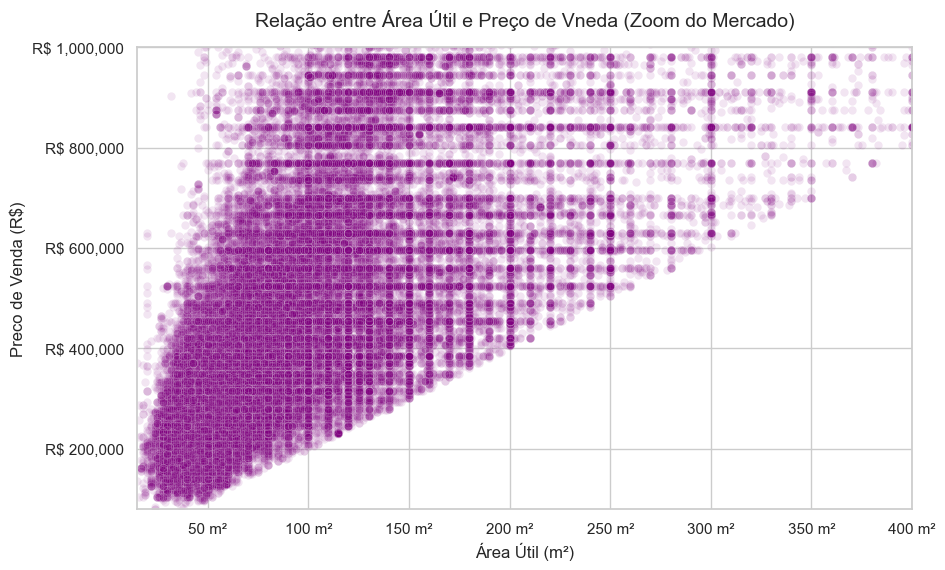

In [47]:
plt.figure(figsize=(10,6))

#Criamos o scatter plot com transparência (alpha para enxergar a densidade de pontos acumulados)
sns.scatterplot(data=df_final, x='area_util', y='preco_venda', alpha=0.1, color='purple')

plt.title('Relação entre Área Útil e Preço de Vneda (Zoom do Mercado)', fontsize=14, pad=15)
plt.xlabel('Área Útil (m²)', fontsize=12)
plt.ylabel('Preco de Venda (R$)', fontsize=12)


# Manter o mesmo Zoom estratégico para avaliar o grosso mercado
plt.xlim(15, 400)
plt.ylim(80000, 1000000)

# Formatação dos eixos
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f} m²"))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f"R$ {y:,.0f}"))

plt.show()

## 12. Quantificação Estatística: Correlação de Pearson

Para validar a hipótese visual de que o preço aumenta proporcionalmente à área útil, calculo o coeficiente de correlação de Pearson entre as variáveis numéricas. Esta etapa quantifica a força da relação linear antes de alimentarmos nossos algoritmos de aprendizado supervisionado.

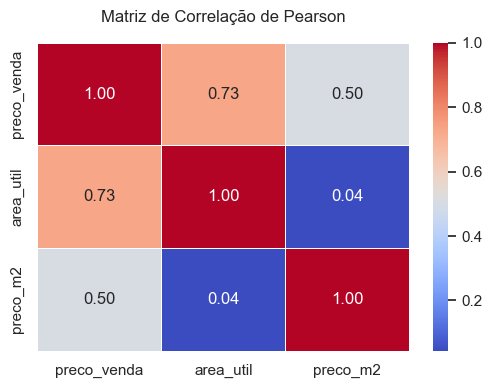

In [48]:
# Calculo de matriz de correlação apenas para as colunas numéricas de interesse
matriz_corr = df_final[['preco_venda', 'area_util', 'preco_m2']].corr()

# configuro o visual do mapa de calor (heatmap)
plt.figure(figsize=(6,4))
sns.heatmap(matriz_corr, annot=True,cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação de Pearson', fontsize=12, pad=15)

plt.show()